<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

## Torção de barras elásticas. Parte III
## Problema 2 <a name="PV132"></a>

A figura representa um veio cilíndrico $ABC$, com diâmetro exterior de 120 mm e comprimento $L=$ 1 m, construído em aço com $G =$ 77 GPa e $\tau_c$ = 145 MPa. O veio é oco no troço $AB$, com uma espessura de parede de 6 mm, e maciço no troço $BC$. Na extremidade $C$ do veio está aplicado um momento de torção $T$, de intensidade desconhecida.

[a)](#A) Deduza a fórmula $T_p= 2\pi\tau_C/3(r_e^3 - r_i^3)$ que permite calcular o momento plástico do troço $AB$ do veio.

[b)](#B) Represente a distribuição de tensões nos dois troços do veio no instante considerado na alínea
anterior.

[c)](#C) Considere que o momento $T$ é progressivamente aumentado até atingir o valor $T_P$. Calcule a rotação $\phi$ da extremidade $C$ no instante em que $T$ atinge $T_P$.

[d)](#D) Determine as tensões residuais nos dois troços e o ângulo de rotação residual da secção $C$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/Au13_P002_i1.jpg"
width="400" height="320">

In [18]:
import numpy as np
import math
from matplotlib import pyplot as plt
from matplotlib.patches import Arc

# Dados
# unidades: m, Pa, N

G = 77.e9
TauC = 145.e6 # unidade: Pa

dABC = 120.e-3
rBC = dABC/2
espAB = 6.e-3
rABe = dABC/2
print('re (veio AB) =',rABe,' m')
rABi = (dABC-2*espAB)/2
print('ri (veio AB) =',rABi,' m')

LABC = 1.
LAB = LABC/2
LBC = LABC/2

re (veio AB) = 0.06  m
ri (veio AB) = 0.054  m


#### a) Deduza a fórmula $T_p= 2\pi\tau_C/3(r_e^3 - r_i^3)$ que permite calcular o momento plástico do troço $AB$ do veio.<a name="A"></a> ([_enunciatum_](#PV132))

As tensões de corte geradas na secção perpendicular ao eixo longitudinal do veio devem estar em equilíbrio estático com o momento de torção exteriormente aplicado.

Considere-se um elemento de área $\mathrm{d}A$ na secção transversal do veio, a uma distância $\rho$ do centro do veio. Em resposta ao momento torsor aplicado, desenvolver-se-à sobre $\mathrm{d}A$ uma tensão de corte $\tau\equiv\tau_{x\theta} $. A força resultante elementar, $\mathrm{d}F$, atuante sobre o elemento $\mathrm{d}A$ é dado pelo produto: $\mathrm{d}F = \tau\,\mathrm{d}A$. Esta força é equilibrada por uma força de igual intensidade mas de sinal contrário, que atua num elemento de área $\mathrm{d}A'$ à distância $-\rho$ em relação ao eixo do veio; pelo que o sumatório das forças é zero. A força $\mathrm{d}F$ exercerá um momento torso em relação ao ponto central do veio:

\begin{equation*}
\mathrm{d}T = \rho\,\mathrm{d}F = \rho(\tau\,\mathrm{d}A)
\end{equation*}

Pelo que o momento resultante gerado pelas tensões de corte, $\tau$, em relação ao eixo do veio, é obtido integrando $\mathrm{d}T$ ao longo da área de secção transversal. Este momento torsor interno deve equilibrar o momento de torção aplicado ao veio tal que:

\begin{equation*}
T = \int \mathrm{d}T = \int \rho\,\tau\mathrm{d}A
\end{equation*}

Para o elemento de área de secção infinitesimal e utilizando coordenadas polares com a seguinte transformação: $\mathrm{d}A = J\mathrm{d}\rho\mathrm{d}\theta $, em que $J=\rho$ (Apêndice A).

\begin{equation*}
T = \int \rho\,\tau\mathrm{d}A = \int \rho^2\,\tau\mathrm{d}\rho\mathrm{d}\theta
\end{equation*}

Como o veio é inteiro a integração em $\theta$ reduz-se a $2\pi$ para:

\begin{equation*}
T = 2\pi \int \rho^2\,\tau\mathrm{d}\rho
\end{equation*}

Nesta expressão a tensão de corte $\tau$ deve ser substituída por uma expressão adequada. Neste caso, porque o veio está no domínio plástico $\tau= \tau_C$; considerando o veio oco no tramo $AB$ resulta finalmente:

\begin{equation*}
T_p = 2\pi\tau_C \int_{r_i}^{r_e} \rho^2\,\mathrm{d}\rho
= 2\pi\tau_C \left[\frac{\rho^2}{2}\right]_{r_i}^{r_e}
= \frac{2\pi}{3}\tau_C (r_e^3 - r_i^3)
\end{equation*}

In [19]:
TpAB = 2/3*np.pi*TauC*(rABe**3 - rABi**3)
print(f'TpAB = {TpAB:.2f} N.m (sinal positivo : sentido anti-horário)')

TpAB = 17776.64 N.m (sinal positivo : sentido anti-horário)


Para o troço $AB$ do veio, o momento torsor crítico é dado de acordo com a fórmula de torção por:

\begin{equation*}
T_C^{AB} = \frac{\tau_C r_e}{J}
\end{equation*}

com $J = J_{AB}$ o segundo momento de área ou momento polar de inércia da área de secção transversal assim definido para um veio oco:

\begin{equation*}
J = \int \rho^2 \mathrm{d}A = \int_\rho\int_\theta \rho^2 (\rho\mathrm{d}\rho\mathrm{d}\theta)
= 2\pi \int_{r_i}^{r_2} \rho^3\mathrm{d}\rho
= \frac{\pi}{2}(r_e^4 - r_i^4)
\end{equation*}

In [20]:
JAB = np.pi/2*(rABe**4 - rABi**4)
print(f'JAB = {JAB:.5e} m^4')

TCAB = TauC*JAB/rABe
print(f'TC (veio AB) = {TCAB:.2f} N.m')

JAB = 7.00095e-06 m^4
TC (veio AB) = 16918.97 N.m


#### b) Represente a distribuição de tensões nos dois troços do veio no instante considerado na alínea anterior.<a name="B"></a> ([_enunciatum_](#PV132))

- Troço $AB$ do veio:

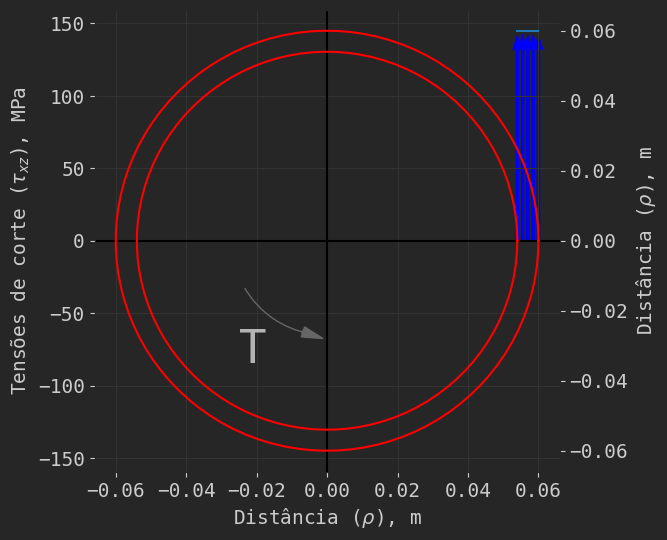

In [21]:
plt.rcParams['axes.facecolor'] = (.15, .15, .15)
plt.rcParams['figure.facecolor'] = (.15, .15, .15)
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 14
# plt.rcParams['text.usetex'] = True
params = {"ytick.color" : (.8, .8, .8),
          "xtick.color" : (.8, .8, .8),
          "grid.color" : (.2, .2, .2),
          "text.color" : (.7, .7, .7),
          "axes.labelcolor" : (.8, .8, .8),
          "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

def torcao(rho,T,J): return T*rho/J

limits = np.array([[-rABe*1.1,rABe*1.1],[-TauC*1.1*1e-6,TauC*1.1*1e-6]])
xp1 = np.linspace(rABi,rABe,5)
yp1 = np.ones(xp1.shape)*TauC*1e-6
fig, ax = plt.subplots(figsize=(6,6))
ax2 = ax.twinx()
ax.plot(xp1,yp1)
ax.quiver(xp1, np.zeros(xp1.shape), np.zeros(xp1.shape), yp1,color='blue', scale=325)
ax.set(xlabel=r'Distância ($\rho$), m', ylabel=r'Tensões de corte ($\tau_{xz}$), MPa')
theta = np.linspace(0, 2*np.pi, 100)
x1i = rABi*np.cos(theta)
x2i = rABi*np.sin(theta)
ax2.plot(x1i, x2i,color='red')
x1e = rABe*np.cos(theta)
x2e = rABe*np.sin(theta)
ax2.plot(x1e, x2e,color='red')
ax2.set(ylabel=r'Distância ($\rho$), m')
x0, y0 = 0, 0
angle = 260
angle_rad = angle * math.pi / 180
arc_radius = rABi
arc = Arc((x0, y0),arc_radius, arc_radius,theta1=210, theta2=260,
          linestyle='solid',color=(0.4,0.4,0.4))
ax2.add_patch(arc)
arc_arrow_length = rABi/2
arc_arrow_dx = arc_arrow_length * math.cos(angle_rad + math.pi / 2)
arc_arrow_dy = arc_arrow_length * math.sin(angle_rad + math.pi / 2)
ax2.arrow(-0.007,-0.026,0.03* 0.005,-.005* 0.01,head_width=0.003,head_length=0.006,color=(0.4,0.4,0.4))
ax2.text(-.025,-.035,'T',fontsize=33)
ax.set_xlim(limits[0,0],limits[0,1])
ax.set_ylim(limits[1,0],limits[1,1])
ax2.set_ylim(limits[0,0],limits[0,1])
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.grid()
plt.show()

- Troço $BC$ do veio:

Verifique-se em que domínio, elástico ou plástico, se encontra o troço $BC$ do veio para o momento torsor aplicado. Considerando por hipótese o domínio elástico, para o qual é válida a fórmula de torção:

\begin{equation*}
\tau_{BC}^\mathrm{max} = \frac{T r_e}{J_{BC}}
\end{equation*}

conclui-se que: $\tau_{BC}^\mathrm{max} < \tau_C$ conclui-se que o troço $BC$ do veio permanece no regime elástico. A tensão de corte máxima que atua no troço $BC$ do veio pode ser determinada pela expressão anterior, considerando o momento de torção plástico determinado na alínea anterior para o troço $AB$ oco do veio:

In [22]:
JBC = np.pi/2*rBC**4
print(f'JBC = {JBC:.5e} m^4')
tauBCmax = TpAB*rBC/JBC
print(f'TauBC max (rho = re) = {tauBCmax*1e-6:.2f} MPa')

JBC = 2.03575e-05 m^4
TauBC max (rho = re) = 52.39 MPa


Numa última verificação, o momento torsor crítico para o veio $BC$ pode ser calculado pela fórmula de torção:

\begin{equation*}
T_C^{BC} = \frac{\tau_C r_e}{J}~,
\quad J_{BC} = \frac{\pi}{2}r_e^4
\end{equation*}

In [23]:
TCBC = TauC*JBC/rBC
print(f'TC (veio BC) = {TCBC:.2f} N.m')

TC (veio BC) = 49197.34 N.m


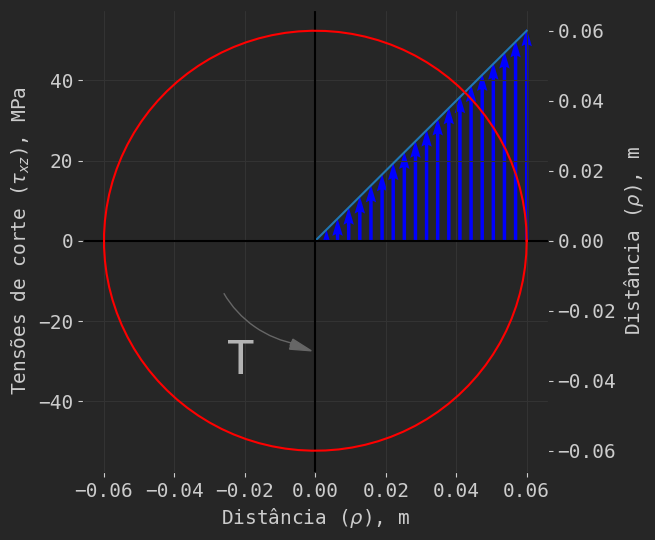

In [24]:
limits = np.array([[-rBC*1.1,rBC*1.1],[-tauBCmax*1.1*1e-6,tauBCmax*1.1*1e-6]])
fig, ax = plt.subplots(figsize=(6,6))
xp1 = np.linspace(0,rBC,20)
yp1 = torcao(xp1,TpAB,JBC)*1e-6
# ax = plt.subplots(figsize=(6,6))
ax2 = ax.twinx()
ax.plot(xp1,yp1)
ax.quiver(xp1, np.zeros(xp1.shape), np.zeros(xp1.shape), yp1,color='blue', scale=115)
ax.set(xlabel=r'Distância ($\rho$), m', ylabel=r'Tensões de corte ($\tau_{xz}$), MPa')
theta = np.linspace(0, 2*np.pi, 100)
ax2.plot(rBC*np.cos(theta), rBC*np.sin(theta), color='red')
ax2.set(ylabel=r'Distância ($\rho$), m')
x0, y0, angle = 0, 0, 260
angle_rad = angle * np.pi / 180
arc = Arc((x0, y0),rBC, rBC,theta1=210, theta2=260, linestyle='solid',color=(0.4,0.4,0.4))
ax2.add_patch(arc)
arc_arrow_length = rBC/2
ax2.arrow(-0.007,-0.0295,0.03* 0.005,-.005* 0.01,head_width=0.003,
          head_length=0.006,color=(0.4,0.4,0.4))
ax2.text(-.025,-.038,'T',fontsize=33)
ax.set_xlim(limits[0,0],limits[0,1])
ax.set_ylim(limits[1,0],limits[1,1])
ax2.set_ylim(limits[0,0],limits[0,1])
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.grid()
plt.show()

#### c) Considere que o momento $T$ é progressivamente aumentado até atingir o valor $T_P$. Calcule a rotação $\phi$ da extremidade $C$ no instante em que $T$ atinge $T_P$.<a name="C"></a> ([_enunciatum_](#PV132))

A rotação angular do veio na secção $C$, $\phi_C$ é dado pelo sumatório:

\begin{equation*}
\phi_{C/A} \equiv \phi_C = \phi_{C/B} + \phi_{B/A} = \phi_{C/B} + \phi_{B}
\end{equation*}

- Troço $BC$ do veio:

Para cálcular o ângulo de rotação $\phi_{C/B}$ é necessário previamente verificar em que domínio, elástico ou plástico, este se encontra para o momento torsor aplicado. Considerando por hipótese o domínio elástico, para o qual é válida a fórmula de torção:

\begin{equation*}
\tau_{BC}^\mathrm{max} = \frac{T r_e}{J_{BC}}
\end{equation*}

conclui-se que: $\tau_{BC}^\mathrm{max} < \tau_C$ conclui-se que o troço $BC$ do veio permanece no regime elástico. Pelo que,

\begin{equation*}
\phi_{C/B} = \frac{T_{BC} L_{BC}}{J_{BC}G}
\end{equation*}

In [25]:
phiCB = TpAB*LBC/JBC/G
print(f'phi C/B = {phiCB:.6f} radianos | {np.rad2deg(phiCB):.3f} º')

phi C/B = 0.005670 radianos | 0.325 º


- Troço $AB$ do veio:

Por sua vez, o $\phi_{B/A} \equiv \phi_{B}$ pode ser calculado no domínio plástico recorrendo à expressão:

\begin{equation*}
\frac{\phi_{B/A}}{c} =
\frac{\phi_C}{\rho_C}
\quad\Leftrightarrow\quad
\phi_B = \left(\frac{r_{e}^{AB}}{r_{i}^{AB}}\right)\phi_C^{AB}
\end{equation*}

onde,

\begin{equation*}
\phi_C^{AB} = \frac{T_CL}{JG} = \frac{\tau_CL}{cG}
\quad\therefore\quad
\phi_C^{AB}= \frac{\tau_CL_{AB}}{r_{e}^{AB}G}
\end{equation*}

In [26]:
phiCAB = TauC*LAB/rABe/G
print(f'phi C (veio AB) = {phiCAB:.6f} radianos | {np.rad2deg(phiCAB):.3f} º')

phiB = rABe/rABi*phiCAB
print(f'phi B/A (veio AB) = {phiB:.6f} radianos | {np.rad2deg(phiB):.3f} º')

phi C (veio AB) = 0.015693 radianos | 0.899 º
phi B/A (veio AB) = 0.017436 radianos | 0.999 º


Finalmente o ângulo de rotação da secção $C$ vem:

In [27]:
phiC = phiB + phiCB
print(f'phi C (secção C) = {phiC:.6f} radianos | {np.rad2deg(phiC):.3f} º')

phi C (secção C) = 0.023107 radianos | 1.324 º


#### d) Determine as tensões residuais nos dois troços e o ângulo de rotação residual da secção $C$.<a name="D"></a> ([_enunciatum_](#PV132))

A rotação do troço $BC$ será recuperada quando o momento torsor for removido, uma vez que este troço do veio se deforma em regime elástico. Por outro lado, o troço $AB$ plastifica completamente, o que significa que existirá um ângulo de rotação residual após carregamento.

No diagrama momento torsor - ângulo de rotação ($T-\phi$) a parte de descarga do momento aplicado será representado por uma reta, com declive igual ao troço linear. De notar que o ângulo de torção não volta a zero depois da remoção do momento torsor aplicado, resultando uma deformação angular permanente obtida por:

\begin{equation*}
\begin{aligned}
\phi_R = \phi - \phi'
\end{aligned}
\end{equation*}

com

\begin{equation*}
\phi = \phi_{B/A} \equiv \phi_{B} = \left(\displaystyle\frac{r_{e}^{AB}}{r_{i}^{AB}}\right)\phi_C^{AB}
\quad\wedge\quad
\phi' = \displaystyle\frac{T_P L_{AB} }{J_{AB}G}
\end{equation*}

em que $\phi$ é o ângulo de rotação do troço do veio $AB$ para a aplicação da deformação plástica desenvolvida, e $\phi'$ é o ângulo recuperado na fase de descarga ($T_PL_{AB}/J_{AB}G$) (porção elástica).

In [28]:
phidescarga  = TpAB*LAB/JAB/G
print(f'phi(descarga) = {phidescarga:.5f} rad | {np.rad2deg(phidescarga):.2f} º')

phiresidual = phiB - phidescarga
print(f'phiresidual = {phiresidual:.5f} rad | {np.rad2deg(phiresidual):.2f} º')

phi(descarga) = 0.01649 rad | 0.94 º
phiresidual = 0.00095 rad | 0.05 º


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/Au13_P002_i2.jpg"
width="600" height="500">

Na descarga a tensão no limite elástico e na extremidade do veio podem ser obtidos por:

\begin{equation*}
\begin{cases}
\tau_1 &=  \displaystyle\frac{(-T)\rho}{J} \left|_{\rho = \rho_C}\right. \\
\tau_2 &=  \displaystyle\frac{(-T)\rho}{J} |_{\rho = c}
\end{cases}
\end{equation*}

In [29]:
tau1 = -TpAB*rABi/JAB
print(f'tau1 = {tau1*1e-6:.2f} MPa')

tau2 = -TpAB*rABe/JAB
print(f'tau2 = {tau2*1e-6:.2f} MPa')

tau1 = -137.12 MPa
tau2 = -152.35 MPa


As tensões residuais são obtidas pelo princípio de sobreposição. Para os pontos radiais no limite de elasticidade e na periferia do veio as tensões residuais são assim obtidas:

\begin{equation*}
\begin{cases}
\tau_1^R &=  \tau_C + \tau_1 \\
\tau_2^R &=  \tau_C + \tau_2
\end{cases}
\end{equation*}

In [30]:
tau1R = TauC + tau1
print(f'tau1 Residual (ri) = {tau1R*1e-6:.2f} MPa')

tau2R = TauC + tau2
print(f'tau2 Residual (re) = {tau2R*1e-6:.2f} MPa')

tau1 Residual (ri) = 7.88 MPa
tau2 Residual (re) = -7.35 MPa


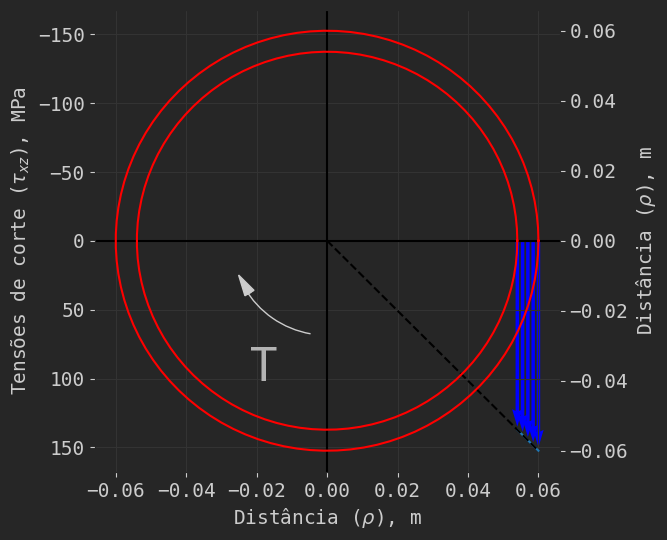

In [31]:
Tplt1 = tau1*1e-6 # unidade: MPa
Tplt2 = tau2*1e-6

limits = np.array([[-rABe*1.1,rABe*1.1],[-Tplt2*1.1,Tplt2*1.1]])
xp1 = np.linspace(rABi,rABe,5)
yp1 = -TpAB*xp1/JAB*1e-6
fig, ax = plt.subplots(figsize=(6,6))
ax2 = ax.twinx()
ax.plot(xp1,-yp1)
ax.plot([0,xp1[-1]],[0,-yp1[-1]],'k--')
ax.quiver(xp1, np.zeros(xp1.shape), np.zeros(xp1.shape), yp1,color='blue', scale=343)
ax.set(xlabel=r'Distância ($\rho$), m', ylabel=r'Tensões de corte ($\tau_{xz}$), MPa')
theta = np.linspace(0, 2*np.pi, 100)
x1i = rABi*np.cos(theta)
x2i = rABi*np.sin(theta)
ax2.plot(x1i, x2i,color='red')
x1e = rABe*np.cos(theta)
x2e = rABe*np.sin(theta)
ax2.plot(x1e, x2e,color='red')
ax2.set(ylabel=r'Distância ($\rho$), m')
x0, y0 = 0, 0
angle = 260
angle_rad = angle * math.pi / 180
arc_radius = rABi
arc = Arc((x0, y0),arc_radius, arc_radius,theta1=210, theta2=260,
          linestyle='solid',color=(0.8,0.8,0.8))
ax2.add_patch(arc)
arc_arrow_length = rABi/2
arc_arrow_dx = arc_arrow_length * math.cos(angle_rad + math.pi / 2)
arc_arrow_dy = arc_arrow_length * math.sin(angle_rad + math.pi / 2)
ax2.arrow(-0.022,-0.015,-.003* 0.01,0.005* 0.01,head_width=0.003,
          head_length=0.006,color=(0.8,0.8,0.8))
ax2.text(-.022,-.04,'T',fontsize=33)
ax.set_xlim(limits[0,0],limits[0,1])
ax.set_ylim(limits[1,0],limits[1,1])
ax2.set_ylim(limits[0,0],limits[0,1])
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.grid()
plt.show()

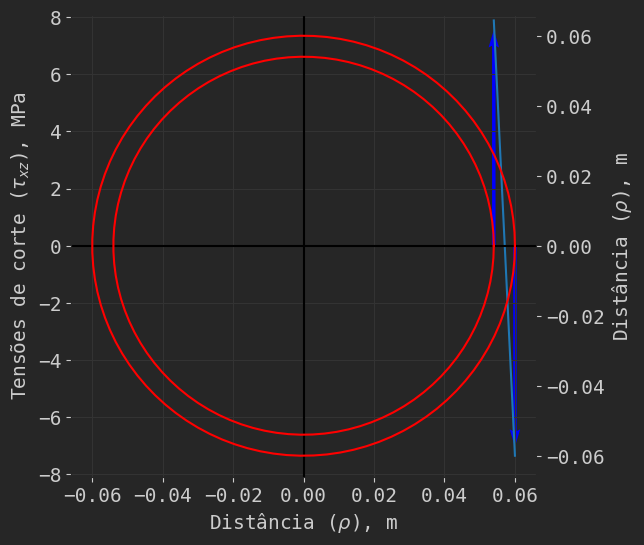

In [32]:
TauR1, TauR2 = tau1R*1e-6, tau2R*1e-6 # unidades: MPa

limits = np.array([[-rABe*1.1,rABe*1.1],[TauR2*1.1,-TauR2*1.1]])
xp1, yp1 = np.array([rABi,rABe]), np.array([TauR1,TauR2])
fig, ax = plt.subplots(figsize=(6,6))
ax2 = ax.twinx()
ax.plot(xp1,yp1)
ax.quiver(xp1, np.zeros(xp1.shape), np.zeros(xp1.shape), yp1,color='blue', scale=17)
ax.set(xlabel=r'Distância ($\rho$), m', ylabel=r'Tensões de corte ($\tau_{xz}$), MPa')
theta = np.linspace(0, 2*np.pi, 100)
x1i, x2i = rABi*np.cos(theta), rABi*np.sin(theta)
ax2.plot(x1i, x2i,color='red')
x1e, x2e = rABe*np.cos(theta), rABe*np.sin(theta)
ax2.plot(x1e, x2e,color='red')
ax2.set(ylabel=r'Distância ($\rho$), m')
ax.set_xlim(limits[0,0],limits[0,1])
ax.set_ylim(limits[1,0],limits[1,1])
ax2.set_ylim(limits[0,0],limits[0,1])
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.grid()
plt.show()


#### Apêndice A. Jacobiano na mudança de coordenadas cartesianas para polares

O jacobiano para a mudança de variáveis de coordenadas cartesianas para coordenadas polares é detereminado considerando

\begin{equation*}
x = f(\rho,\theta) = \rho\cos\theta~, \quad y = g(\rho,\theta) = \rho\sin\theta
\end{equation*}

O Jacobiano da transformação é expresso pelo seguinte determinante:

\begin{equation*}
J(\rho,\theta) = \frac{\partial (x,y)}{\partial (\rho,\theta)} =
\begin{vmatrix}
\displaystyle\frac{\partial x}{\partial \rho} & \displaystyle\frac{\partial y}{\partial \rho} \\
\displaystyle\frac{\partial x}{\partial \theta} & \displaystyle\frac{\partial y}{\partial \theta} \\
\end{vmatrix}
=
\begin{vmatrix}
\cos\theta  & \sin\theta\\
-r\sin\theta  & -r\cos\theta\\
\end{vmatrix} =
(\cos\theta)(-r\cos\theta) - (-r\sin\theta)(\sin\theta) = \rho
\end{equation*}

##### Bibliografia

[1]  Ferdinand P. Beer, E. Russell Johnston Jr., John T. DeWolf, David F. Mazurek. Mechanics of Materials. McGraw-Hill Education, 2014.

[2] Russell C. Hibbeler. Mechanics of Materials. Pearson, 2016.

[3] Timothy A. Philpot. Mechanics of materials: an integrated learning system. John Wiley & Sons, 2017.

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
